# 0.1 - MNIST Double Digit Number Dataset Generation
Generating a double double digit number images dataset from MNIST original datasets.

## 1: Dependencies and Imports

In [19]:
%pip install torch torchvision

Note: you may need to restart the kernel to use updated packages.


In [20]:
# Standard library
import glob
import os
import random

# Third-party
import matplotlib.pyplot as plt
import torch
from torchvision import datasets, transforms

## 2: Load Original Data

In [21]:

# Download MNIST original datasets.
mnist_train = datasets.MNIST(root='../data', train=True, download=True, transform=transforms.ToTensor())
mnist_test = datasets.MNIST(root='../data', train=False, download=True, transform=transforms.ToTensor())

In [22]:
# Define the path where the raw files are stored
raw_folder = '../data/MNIST/raw'

# Find all files ending in .gz and delete them to reduce redundancy
gz_files = glob.glob(os.path.join(raw_folder, '*.gz'))

if gz_files:
    print("\nRemoving redundant compressed files...")
    for file in gz_files:
        os.remove(file)
        print(f"Deleted: {file}")
    print("Cleanup complete! Only uncompressed files remain.")
else:
    print("\nNo .gz files found. Already cleaned up!")


No .gz files found. Already cleaned up!


## 3: Transform Data

In [23]:
class DoubleDigitMNIST(torch.utils.data.Dataset):
    """Dataset that combines two MNIST digits into a single image."""
    
    def __init__(self, root_dir='../data', train=True, length=60000):
        self.mnist = datasets.MNIST(
            root=root_dir, 
            train=train, 
            download=True, 
            transform=transforms.ToTensor()
        )
        self.length = length
        
        # Group indices by label for efficient retrieval
        self.indices_by_label = {i: [] for i in range(10)}
        for idx, label in enumerate(self.mnist.targets):
            self.indices_by_label[label.item()].append(idx)
        
    def __len__(self):
        return self.length
        
    def __getitem__(self, _):
        # Logic matches the original range (0 to 27)
        combined_label = random.randint(0, 27)
        
        # Decompose the combined label into two digits
        digit1 = combined_label // 10  
        digit2 = combined_label % 10   
        
        # Select random samples for each digit
        idx1 = random.choice(self.indices_by_label[digit1])
        idx2 = random.choice(self.indices_by_label[digit2])
        
        img1, _ = self.mnist[idx1]
        img2, _ = self.mnist[idx2]
        
        # Concatenate images horizontally
        combined_img = torch.cat((img1, img2), dim=2)
        
        return combined_img, combined_label

# Initialization and verification
print("Loading dataset...")
train_dataset = DoubleDigitMNIST(root_dir='../data', train=True, length=60000)
print(f"Total images ready: {len(train_dataset)}")

Loading dataset...
Total images ready: 60000


In [24]:
# 2. Instantiate the training dataset
print("Loading local dataset...")

# Initializing with default parameters; download=True in the class ensures data availability
train_dataset_2digits = DoubleDigitMNIST(root_dir='../data', train=True)

print(f"Total images ready: {len(train_dataset_2digits)}")

Loading local dataset...
Total images ready: 60000


In [25]:
# Ensure the output directory exists
os.makedirs('../data/MNIST_2DIGITS', exist_ok=True)

def generate_and_save_dataset(root_dir='../data', train=True, num_samples=60000):
    """Generates a synthetic dataset of combined MNIST digits and saves it to disk."""
    mnist = datasets.MNIST(
        root=root_dir, 
        train=train, 
        download=True, 
        transform=transforms.ToTensor()
    )
    
    # Map labels to indices for fast lookup using targets attribute
    indices_by_label = {i: [] for i in range(10)}
    for idx, label in enumerate(mnist.targets):
        indices_by_label[label.item()].append(idx)
        
    images = []
    labels = []
    
    split_name = "Training" if train else "Test"
    print(f"Generating {num_samples} samples for the {split_name} set...")
    
    for _ in range(num_samples):
        # Select target combined label (0-27) and split into digits
        combined_label = random.randint(0, 27)
        d1, d2 = combined_label // 10, combined_label % 10
        
        # Retrieve random images for both digits
        idx1 = random.choice(indices_by_label[d1])
        idx2 = random.choice(indices_by_label[d2])
        
        img1, _ = mnist[idx1]
        img2, _ = mnist[idx2]
        
        # Concatenate horizontally and store
        combined_img = torch.cat((img1, img2), dim=2) 
        images.append(combined_img)
        labels.append(combined_label)
        
    # Convert lists to tensors and save as a dictionary
    data_dict = {
        'images': torch.stack(images), 
        'labels': torch.tensor(labels)
    }
    
    file_name = "train_2digits.pt" if train else "test_2digits.pt"
    save_path = os.path.join('../data/MNIST_2DIGITS', file_name)
    
    torch.save(data_dict, save_path)
    print(f"Dataset saved successfully at: {save_path}\n")

In [26]:
# Execute dataset generation for both splits
generate_and_save_dataset(train=True, num_samples=60000)
generate_and_save_dataset(train=False, num_samples=10000)

Generating 60000 samples for the Training set...
Dataset saved successfully at: ../data/MNIST_2DIGITS/train_2digits.pt

Generating 10000 samples for the Test set...
Dataset saved successfully at: ../data/MNIST_2DIGITS/test_2digits.pt



## 4: Show Data Results Examples

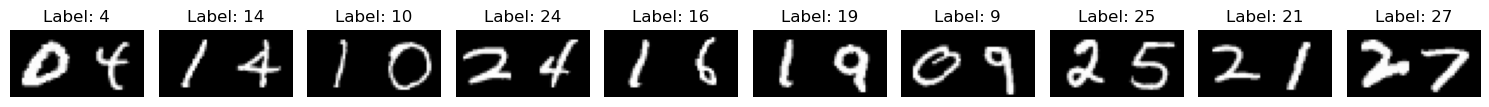

In [27]:
# Visualize a random selection of samples
fig, axes = plt.subplots(1, 10, figsize=(15, 3))

for i in range(10):
    # Select a random index from the training set
    idx = random.randint(0, len(train_dataset_2digits) - 1)
    img, label = train_dataset_2digits[idx]
    
    # Display image and its corresponding combined label
    axes[i].imshow(img.squeeze(), cmap='gray')
    axes[i].set_title(f"Label: {label}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()